In [2]:
import numpy as np
import matplotlib.pyplot as plt

from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.units import dbm_to_w, w_to_dbm
from rfmodel.meas.spectrum_analyser import spectrum_analyser
from rfmodel.plot_utils.spectrum_plot import plot_top_spectrum

import rfmodel.channel.registry


# Load pipeline from YAML
cfg = load_yaml(r".\pipeline_channel_demo.yaml")
pipe = pipeline_from_config(cfg)

In [3]:
# Signal setup
fs = 5_000_000
f0 = 50_000
dur = 0.02
t = np.arange(0, dur, 1 / fs)

Pin_dbm = 0.0
Pin_W = dbm_to_w(Pin_dbm)

# Complex tone with average power = Pin_W
A = np.sqrt(Pin_W)
x_in = A * np.exp(1j * 2 * np.pi * f0 * t)

sig_in = Signal(
    x=x_in,
    fs_hz=fs,
    meta={"Pin_dbm": Pin_dbm},
)

# Run channel
sig_out, taps = pipe.run(sig_in, taps=["chan1"])


In [4]:
pipe.blocks

[ChannelBlock(name='chan1', enabled=True)]

In [5]:
# Basic power measurements
Pin_meas_W = np.mean(np.abs(sig_in.x) ** 2)
Pout_meas_W = np.mean(np.abs(sig_out.x) ** 2)

print("Input power  (W):  ", Pin_meas_W)
print("Input power  (dBm):", w_to_dbm(Pin_meas_W))
print("Output power (W):  ", Pout_meas_W)
print("Output power (dBm):", w_to_dbm(Pout_meas_W))


Input power  (W):   0.0009999999999999994
Input power  (dBm): -2.8929823996598624e-15
Output power (W):   5.753436507426957e-11
Output power (dBm): -72.40072675240047


In [6]:
# Net attenuation
gain_lin = Pout_meas_W / Pin_meas_W
gain_db = 10 * np.log10(gain_lin)
print("Net channel gain (dB):", gain_db)

Net channel gain (dB): -72.40072675240047


In [7]:
# Estimate added noise power by subtracting ideal scaled tone
# Useful when channel = pathloss + awgn
x_chan = taps["chan1"].x

alpha_hat = np.vdot(sig_in.x, x_chan) / np.vdot(sig_in.x, sig_in.x)
x_ideal = alpha_hat * sig_in.x
n_hat = x_chan - x_ideal

Pn_est_W = np.mean(np.abs(n_hat) ** 2)
Ps_est_W = np.mean(np.abs(x_ideal) ** 2)
snr_est_db = 10 * np.log10(Ps_est_W / Pn_est_W)

print("Estimated signal power after channel (W):", Ps_est_W)
print("Estimated noise power  after channel (W):", Pn_est_W)
print("Estimated noise power  after channel (dBm):", w_to_dbm(Pn_est_W))
print("Estimated SNR after channel (dB):", snr_est_db)


Estimated signal power after channel (W): 5.696531815405826e-11
Estimated noise power  after channel (W): 5.690469202112761e-13
Estimated noise power  after channel (dBm): -92.44851922798719
Estimated SNR after channel (dB): 20.004624500768596


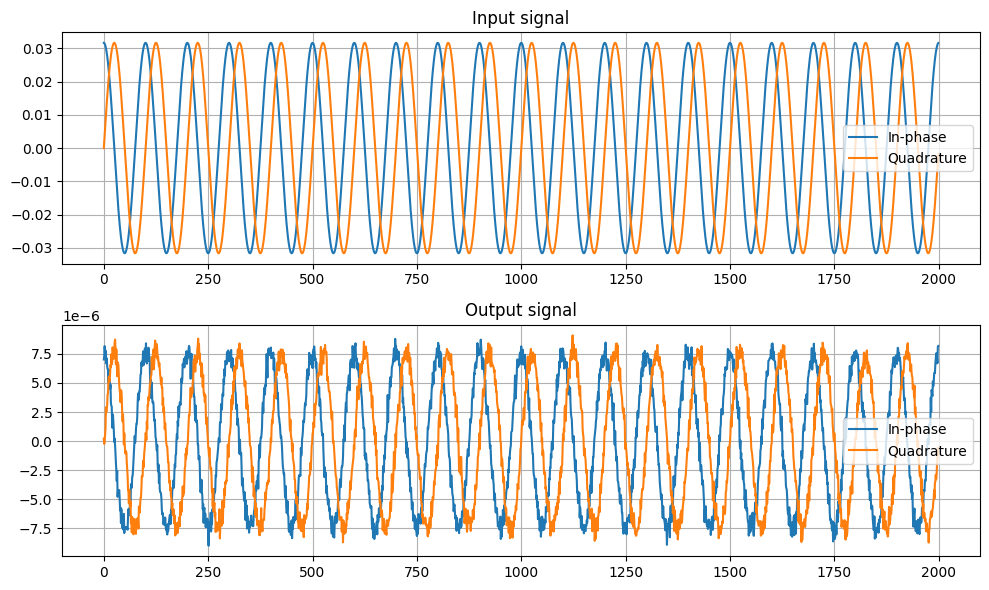

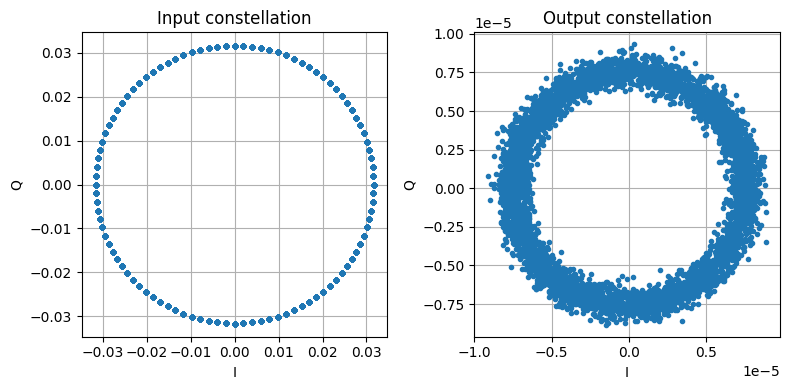

In [8]:
# Time-domain plot
nplot = 2000
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(np.real(sig_in.x[:nplot]), label="In-phase")
plt.plot(np.imag(sig_in.x[:nplot]), label="Quadrature")
plt.title("Input signal")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(np.real(sig_out.x[:nplot]), label="In-phase")
plt.plot(np.imag(sig_out.x[:nplot]), label="Quadrature")
plt.title("Output signal")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Constellation
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(np.real(sig_in.x[:5000]), np.imag(sig_in.x[:5000]), ".")
plt.title("Input constellation")
plt.xlabel("I")
plt.ylabel("Q")
plt.grid(True)
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.plot(np.real(sig_out.x[:5000]), np.imag(sig_out.x[:5000]), ".")
plt.title("Output constellation")
plt.xlabel("I")
plt.ylabel("Q")
plt.grid(True)
plt.axis("equal")

plt.tight_layout()
plt.show()
